# Model Training

### Importing required packages


In [61]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier,AdaBoostClassifier,GradientBoostingClassifier

from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC

from xgboost import XGBClassifier
from catboost import CatBoostClassifier

In [62]:
df_clean=pd.read_csv("data/cleaned_telco_churn.csv")

In [63]:
df_clean["Churn"] = df_clean["Churn"].map({"No": 0,"Yes": 1})
print(df_clean["Churn"].unique())

[0 1]


In [64]:
df_clean.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,0
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,0
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,1
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,0
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,1


In [65]:
X=df_clean.drop(columns=["customerID","Churn"])

In [66]:
y=df_clean["Churn"]

In [67]:
numerical_features = X.select_dtypes(include=["int64", "float64"]).columns
categorical_features = X.select_dtypes(include=["object"]).columns

In [68]:
print("Numerical Features:")
print(numerical_features)
print("Categorical Features:")
print(categorical_features)

Numerical Features:
Index(['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges'], dtype='str')
Categorical Features:
Index(['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines',
       'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
       'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract',
       'PaperlessBilling', 'PaymentMethod'],
      dtype='str')


In [69]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42,stratify=y)

In [70]:
num_features = X.select_dtypes(exclude="object").columns
cat_features = X.select_dtypes(include="object").columns

In [71]:
from sklearn.preprocessing import (OneHotEncoder,StandardScaler)
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

In [72]:
num_pipeline = Pipeline(steps=[("scaler", StandardScaler())])

In [73]:
cat_pipeline = Pipeline(steps=[("one_hot_encoder",OneHotEncoder(handle_unknown="ignore"))])

In [74]:
preprocessor = ColumnTransformer([("num_pipeline",num_pipeline,numerical_features),("cat_pipeline",cat_pipeline,categorical_features)]
)

In [75]:
X_train = preprocessor.fit_transform(X_train)

In [76]:
X_test = preprocessor.transform(X_test)

In [77]:
models = {
    "Logistic Regression": LogisticRegression(random_state=42),
    "KNN": KNeighborsClassifier(),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(random_state=42),
    "AdaBoost": AdaBoostClassifier(random_state=42),
    "SVC": SVC(probability=True, random_state=42),
    "XGBoost": XGBClassifier(random_state=42),
    "CatBoost": CatBoostClassifier(verbose=False, random_state=42)
    }

In [78]:
from sklearn.metrics import (accuracy_score,precision_score,recall_score,f1_score,roc_auc_score)

In [79]:
lr = LogisticRegression(random_state=42)

In [106]:
lr.fit(X_train, y_train)

,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",42
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solve

In [81]:
y_pred = lr.predict(X_test)

In [82]:
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:",accuracy)

Accuracy: 0.8038379530916845


In [83]:
precision = precision_score(y_test, y_pred)
print("Precision:",precision)

Precision: 0.6484848484848484


In [84]:
recall = recall_score(y_test, y_pred)
print("Recall:", recall)

Recall: 0.5721925133689839


In [85]:
f1 = f1_score(y_test, y_pred)
print("F1 Score:", f1)

F1 Score: 0.6079545454545454


In [86]:
y_prob = lr.predict_proba(X_test)[:, 1]

In [87]:
roc_auc = roc_auc_score(y_test, y_prob)
print("ROC-AUC:", roc_auc)

ROC-AUC: 0.8359290473207676


In [88]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

In [89]:
cm=confusion_matrix(y_test, y_pred)
print(cm)

[[917 116]
 [160 214]]


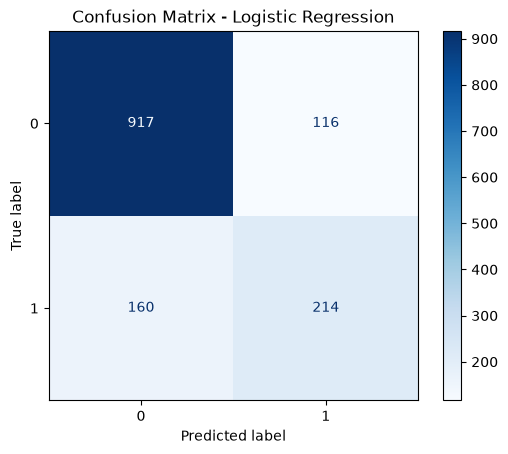

In [90]:
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap="Blues")
plt.title("Confusion Matrix - Logistic Regression")
plt.show()

In [91]:
def evaluate_model(model, X_train, y_train, X_test, y_test):
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]
    results = {
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1 Score": f1_score(y_test, y_pred),
        "ROC-AUC": roc_auc_score(y_test, y_prob)
    }
    return results

In [92]:
lr_results = evaluate_model(
    model=LogisticRegression(random_state=42),
    X_train=X_train,
    y_train=y_train,
    X_test=X_test,
    y_test=y_test
)

In [93]:
print(lr_results)

{'Accuracy': 0.8038379530916845, 'Precision': 0.6484848484848484, 'Recall': 0.5721925133689839, 'F1 Score': 0.6079545454545454, 'ROC-AUC': 0.8359290473207676}


In [94]:
pd.DataFrame([lr_results], index=["Logistic Regression"])

,Accuracy,Precision,Recall,F1 Score,ROC-AUC
Logistic Regression,0.803838,0.648485,0.572193,0.607955,0.835929


In [95]:
results = {}
for model_name, model in models.items():
    print(f"Training {model_name}...")
    results[model_name] = evaluate_model(
        model=model,
        X_train=X_train,
        y_train=y_train,
        X_test=X_test,
        y_test=y_test
    )
print("Completed")

Training Logistic Regression...
Training KNN...
Training Decision Tree...
Training Random Forest...
Training Gradient Boosting...
Training AdaBoost...
Training SVC...
Training XGBoost...
Training CatBoost...
Completed


In [96]:
results_df = pd.DataFrame(results).T

In [97]:
results_df = results_df.round(4)

In [98]:
results_df.sort_values(
    by="ROC-AUC",
    ascending=False,
    inplace=True
)

In [99]:
results_df

,Accuracy,Precision,Recall,F1 Score,ROC-AUC
Gradient Boosting,0.7967,0.6429,0.5294,0.5806,0.8386
Logistic Regression,0.8038,0.6485,0.5722,0.6080,0.8359
AdaBoost,0.7903,0.6262,0.5241,0.5706,0.8356
CatBoost,0.7818,0.6077,0.5053,0.5518,0.8263
Random Forest,0.7875,0.6307,0.4840,0.5477,0.8137
XGBoost,0.7690,0.5710,0.5267,0.5480,0.8119
SVC,0.7918,0.6401,0.4947,0.5581,0.7886
KNN,0.7612,0.5480,0.5802,0.5636,0.7799
Decision Tree,0.7306,0.4934,0.4973,0.4953,0.6565


### Insights
Model Selection Strategy: Models are initially ranked using ROC-AUC to compare their overall discriminative ability. Final candidates are selected after considering F1-score, Recall, and confusion matrices to ensure the chosen model aligns with the business objective of identifying customers likely to churn.

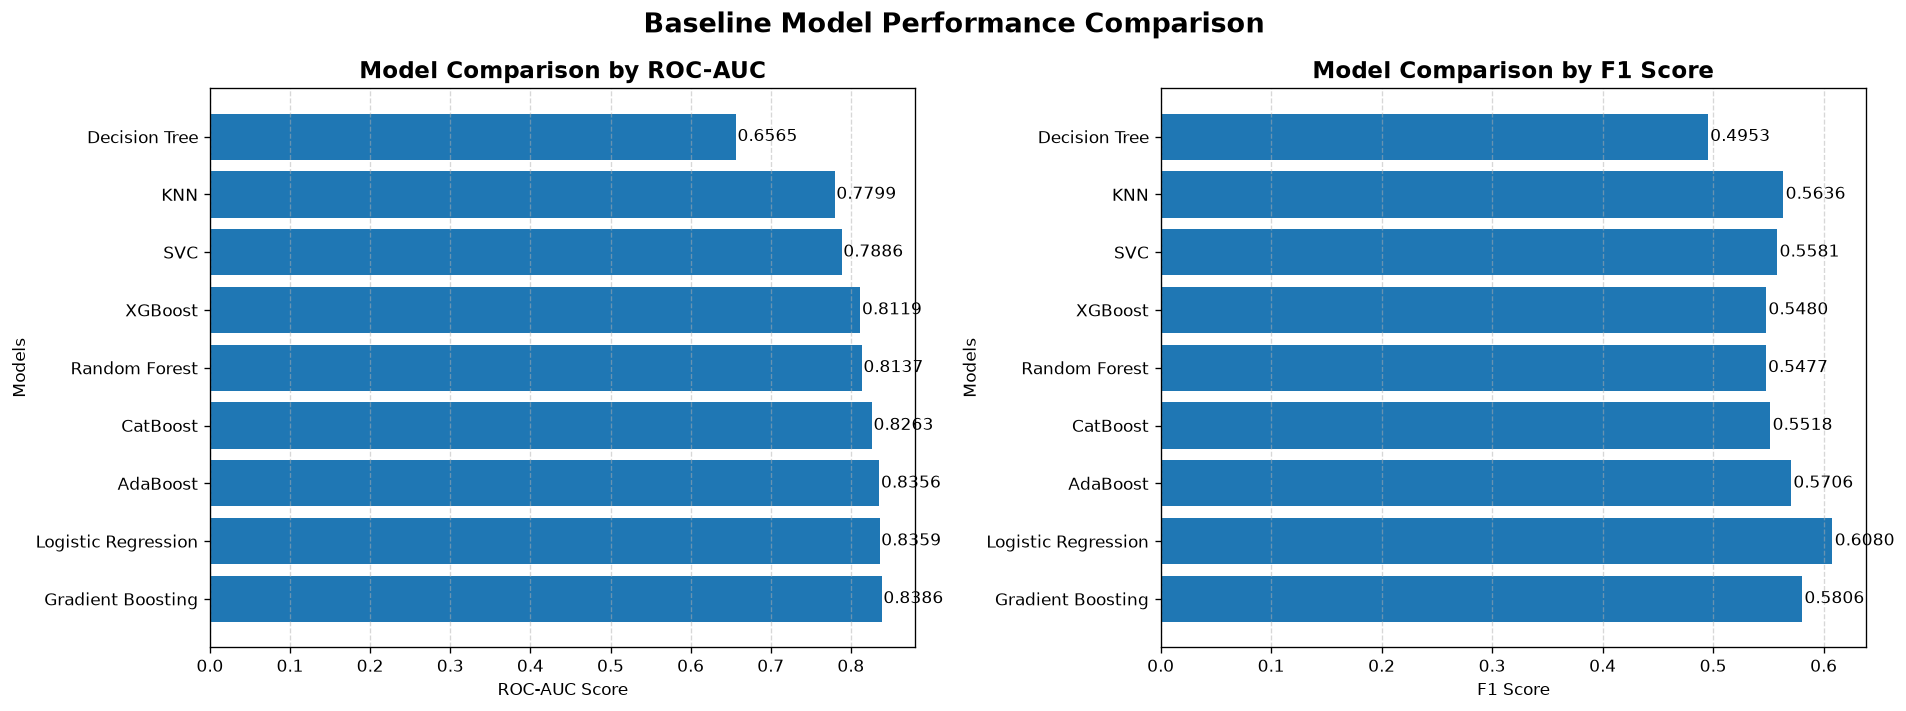

In [100]:
import matplotlib.pyplot as plt
fig, axes = plt.subplots(1, 2, figsize=(16, 6), dpi=120)

#ROC-AUC
axes[0].barh(results_df.index, results_df["ROC-AUC"])

axes[0].set_title("Model Comparison by ROC-AUC", fontsize=14, fontweight="bold")
axes[0].set_xlabel("ROC-AUC Score")
axes[0].set_ylabel("Models")
axes[0].grid(axis="x", linestyle="--", alpha=0.5)

# Add values
for i, value in enumerate(results_df["ROC-AUC"]):
    axes[0].text(
        value + 0.002,
        i,
        f"{value:.4f}",
        va="center",
        fontsize=10
    )

#F1 Score
axes[1].barh(results_df.index, results_df["F1 Score"])

axes[1].set_title("Model Comparison by F1 Score", fontsize=14, fontweight="bold")
axes[1].set_xlabel("F1 Score")
axes[1].set_ylabel("Models")
axes[1].grid(axis="x", linestyle="--", alpha=0.5)

# Add values
for i, value in enumerate(results_df["F1 Score"]):
    axes[1].text(
        value + 0.002,
        i,
        f"{value:.4f}",
        va="center",
        fontsize=10
    )

plt.suptitle(
    "Baseline Model Performance Comparison",
    fontsize=16,
    fontweight="bold"
)
plt.tight_layout()
plt.show()

### Key Observations
-Logistic Regression achieved the highest F1 Score and Accuracy.

-Gradient Boosting achieved the highest ROC-AUC.


-Decision Tree performed worst across all metrics.

-CatBoost and XGBoost may benefit from hyperparameter tuning.

-Logistic Regression is a strong baseline despite its simplicity.

In [101]:
from sklearn.metrics import accuracy_score, f1_score
def evaluate_train_test(model, X_train, y_train, X_test, y_test):

    # Train the model
    model.fit(X_train, y_train)

    # Predictions
    train_pred = model.predict(X_train)
    test_pred = model.predict(X_test)

    # Metrics
    results = {
        "Train Accuracy": accuracy_score(y_train, train_pred),
        "Test Accuracy": accuracy_score(y_test, test_pred),
        "Train F1": f1_score(y_train, train_pred),
        "Test F1": f1_score(y_test, test_pred)
    }

    return results

In [102]:
generalization_results = {}
for model_name, model in models.items():
    print(f"Evaluating {model_name}...")
    generalization_results[model_name] = evaluate_train_test(
        model=model,
        X_train=X_train,
        y_train=y_train,
        X_test=X_test,
        y_test=y_test
    )

Evaluating Logistic Regression...
Evaluating KNN...
Evaluating Decision Tree...
Evaluating Random Forest...
Evaluating Gradient Boosting...
Evaluating AdaBoost...
Evaluating SVC...
Evaluating XGBoost...
Evaluating CatBoost...


In [103]:
generalization_df = pd.DataFrame(generalization_results).T
generalization_df = generalization_df.round(4)

In [104]:
generalization_df["Accuracy Gap"] = (
    generalization_df["Train Accuracy"]
    - generalization_df["Test Accuracy"]
).round(4)

generalization_df["F1 Gap"] = (
    generalization_df["Train F1"]
    - generalization_df["Test F1"]
).round(4)

In [105]:
generalization_df = generalization_df.sort_values(
    by="Accuracy Gap",
    ascending=False
)

generalization_df

,Train Accuracy,Test Accuracy,Train F1,Test F1,Accuracy Gap,F1 Gap
Decision Tree,0.9988,0.7306,0.9977,0.4953,0.2682,0.5024
Random Forest,0.9988,0.7875,0.9977,0.5477,0.2113,0.4500
XGBoost,0.9442,0.7690,0.8925,0.5480,0.1752,0.3445
CatBoost,0.8756,0.7818,0.7436,0.5518,0.0938,0.1918
KNN,0.8325,0.7612,0.6738,0.5636,0.0713,0.1102
Gradient Boosting,0.8302,0.7967,0.6467,0.5806,0.0335,0.0661
SVC,0.8201,0.7918,0.6108,0.5581,0.0283,0.0527
AdaBoost,0.8062,0.7903,0.5981,0.5706,0.0159,0.0275
Logistic Regression,0.8046,0.8038,0.5996,0.6080,0.0008,-0.0084
